# Problem Statement 3: Handling OOV Words in HMMs  
## Title: Unknown Word Handling and Smoothing in POS Tagging

---

## Group Details

| Field | Details |
|---|---|
| **Group Number** | 125 |
| **Domain** | Gaming Reviews and Online Gaming Discussions |
| **Dataset** | 23K Reddit Gaming Comments with Sentiments Dataset containing gaming discussions, player opinions, reactions, sentiment annotations, and informal Reddit conversations from gaming communities |
| **Dataset Source** | https://www.kaggle.com/datasets/sainitishmitta04/23k-reddit-gaming-comments-with-sentiments-dataset |

---

## Team Members

| Member Name | BITS ID | Contribution (%) |
|---|---|---|
| Hemesh Joshi | 2025AA05046 | 100% |
| Sukrit Sarkar | 2025AB05235 | 100% |
| Rankit Agarwal | 2025AB05296 | 100% |
| Wali Haider | 2025AB05295 | 100% |
| Praveen T | 2024AC05680 | 100% |

---

## Setup & Imports

In [145]:
import pandas as pd
import re
import nltk
from collections import defaultdict, Counter
import os
import zipfile
from nltk.probability import FreqDist
import random
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from matplotlib import pyplot as plt
import math
from tabulate import tabulate

In [146]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## Task 1 — Dataset Loading, Sentence Parsing & Frequency Distribution (1 Mark)

For this assignment, a gaming-domain NLP dataset was selected from Kaggle containing Reddit gaming comments annotated with sentiment labels. The dataset consists of real-world player discussions, opinions, reactions, gaming slang, abbreviations, and informal conversational text collected from gaming-related Reddit communities. Such data is highly suitable for Natural Language Processing (NLP) tasks including Part-of-Speech (POS) tagging, Out-of-Vocabulary (OOV) word handling, and frequency-based linguistic analysis.

The dataset was loaded and preprocessed using Python. The first 10,000 comments were extracted, cleaned, tokenized, and parsed for POS tagging experiments. A frequency distribution of words was then generated to identify the most commonly occurring gaming-related terms and informal vocabulary patterns present in the corpus.

### Dataset Information

| Field | Details |
|---|---|
| **Dataset Name** | 23K Reddit Gaming Comments with Sentiments Dataset |
| **Domain** | Gaming Discussions and Reddit Comments |
| **Source** | https://www.kaggle.com/datasets/sainitishmitta04/23k-reddit-gaming-comments-with-sentiments-dataset |
| **Dataset Type** | Text-based NLP Dataset |
| **Primary Use** | POS Tagging, OOV Analysis, Tokenization, Frequency Distribution |

### Objective of Task

The primary objective of this task is to:
- Load and preprocess a gaming-domain text dataset
- Parse sentences/comments into tokens
- Perform POS tagging preparation
- Analyze vocabulary distribution using frequency counts
- Identify gaming-specific and informal OOV words commonly found in Reddit discussions

In [147]:
DATASET_FOLDER = "23k-reddit-gaming-comments-with-sentiments-dataset"
CSV_FILE = "cleaned_comments.csv"

# Check if dataset already exists

if not os.path.exists(f"{DATASET_FOLDER}/{CSV_FILE}"):

    print("Dataset not found locally.")
    print("Downloading dataset from Kaggle...\n")

    # Kaggle dataset download command
    os.system(
        "python -m kaggle datasets download -d sainitishmitta04/23k-reddit-gaming-comments-with-sentiments-dataset"
    )

    print("\nExtracting dataset...\n")

    # Extract ZIP
    with zipfile.ZipFile(
        "23k-reddit-gaming-comments-with-sentiments-dataset.zip",
        "r"
    ) as zip_ref:

        zip_ref.extractall(DATASET_FOLDER)

    print("Dataset downloaded and extracted successfully.")

else:

    print("Dataset already exists locally.")



Dataset already exists locally.


In [148]:
# Load Dataset

df = pd.read_csv(f"{DATASET_FOLDER}/{CSV_FILE}")
print("\nDataset Loaded Successfully\n")
print(df.head())

# Select comments column
text_column = 'comment'

# Basic text cleaning
def clean_text(text):
    text = str(text).lower()
    # remove urls
    text = re.sub(r"http\S+", "", text)
    # keep only letters/numbers/basic punctuation
    text = re.sub(r"[^a-zA-Z0-9\s\.\!\?]", " ", text)
    return text

sentences = df['comment'].dropna().tolist()



Dataset Loaded Successfully

   Unnamed: 0                                            comment sentiment
0           0  dont think like game havent even played minute...  negative
1           1  leave farm smaller creature either wait help k...  negative
2           2  nothing beat feeling get see fall love like ye...  positive
3           3  also theyre made paper edit tried make gif fai...  negative
4           4  haha exactly brother tried get wow run raid ge...  positive


In [149]:
# Parse first 10,000 sentences/comments
sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

# First 10,000 sentences/comments
sentences = sentences[:10000]
print("Total sentences:", len(sentences))

# Show sample
print(sentences[:5])

Total sentences: 10000
['dont think like game havent even played minute still tutorial', 'leave farm smaller creature either wait help kill click button', 'nothing beat feeling get see fall love like year ago', 'also theyre made paper edit tried make gif failed here video', 'haha exactly brother tried get wow run raid get level faster get better gear first need min level lvl ok let couple quest get quest collect apple']


In [150]:
# Tokenization + POS Tagging
tagged_sentences = []
for sentence in sentences:
    tokens = word_tokenize(sentence)
    if len(tokens) > 0:
        tagged = pos_tag(tokens)
        tagged_sentences.append(tagged)
print(tagged_sentences[:3])

[[('dont', 'RB'), ('think', 'VBP'), ('like', 'IN'), ('game', 'NN'), ('havent', 'NN'), ('even', 'RB'), ('played', 'VBD'), ('minute', 'NN'), ('still', 'RB'), ('tutorial', 'JJ')], [('leave', 'VB'), ('farm', 'NN'), ('smaller', 'JJR'), ('creature', 'NN'), ('either', 'CC'), ('wait', 'NN'), ('help', 'NN'), ('kill', 'VB'), ('click', 'JJ'), ('button', 'NN')], [('nothing', 'NN'), ('beat', 'NN'), ('feeling', 'NN'), ('get', 'VB'), ('see', 'JJ'), ('fall', 'NN'), ('love', 'NN'), ('like', 'IN'), ('year', 'NN'), ('ago', 'RB')]]


In [151]:

# Display sample tagged sentences
print("\nSample POS Tagged Sentences:\n")
for i in range(5):
    print(f"Sentence {i+1}:\n")
    print(tagged_sentences[i])

# Build frequency distribution of words

all_words = []
for sentence in sentences:
    tokens = word_tokenize(sentence)
    all_words.extend(tokens)
freq_dist = FreqDist(all_words)

# Display most common words
print("\nMost Common Words:\n")
print(freq_dist.most_common(20))


Sample POS Tagged Sentences:

Sentence 1:

[('dont', 'RB'), ('think', 'VBP'), ('like', 'IN'), ('game', 'NN'), ('havent', 'NN'), ('even', 'RB'), ('played', 'VBD'), ('minute', 'NN'), ('still', 'RB'), ('tutorial', 'JJ')]
Sentence 2:

[('leave', 'VB'), ('farm', 'NN'), ('smaller', 'JJR'), ('creature', 'NN'), ('either', 'CC'), ('wait', 'NN'), ('help', 'NN'), ('kill', 'VB'), ('click', 'JJ'), ('button', 'NN')]
Sentence 3:

[('nothing', 'NN'), ('beat', 'NN'), ('feeling', 'NN'), ('get', 'VB'), ('see', 'JJ'), ('fall', 'NN'), ('love', 'NN'), ('like', 'IN'), ('year', 'NN'), ('ago', 'RB')]
Sentence 4:

[('also', 'RB'), ('theyre', 'NN'), ('made', 'VBD'), ('paper', 'NN'), ('edit', 'NN'), ('tried', 'VBD'), ('make', 'VBP'), ('gif', 'NN'), ('failed', 'VBD'), ('here', 'RB'), ('video', 'JJ')]
Sentence 5:

[('haha', 'NN'), ('exactly', 'RB'), ('brother', 'RB'), ('tried', 'JJ'), ('get', 'VB'), ('wow', 'JJ'), ('run', 'NN'), ('raid', 'VBD'), ('get', 'VB'), ('level', 'JJ'), ('faster', 'RBR'), ('get', 'VB'), ('b

## Task 2 — HMM Training & Laplace (Add-1) Smoothing on Emission Probabilities (2 Marks)

A **Bigram Hidden Markov Model (HMM)** was trained using the tagged Reddit gaming-comments dataset. The model estimates:

- **Transition Probabilities:**
  Probability of the current POS tag occurring given the previous POS tag.

- **Emission Probabilities:**
  Probability of a word being generated from a particular POS tag.

Since Reddit gaming discussions contain informal text, abbreviations, usernames, slang, emojis, and newly coined gaming terms, many words may not appear during training. To handle these unseen or rare words effectively, **Laplace (Add-1) smoothing** was applied to the emission probabilities.

### Transition Probability

The transition probability is calculated as:

\[
P(t_i \mid t_{i-1}) = \frac{Count(t_{i-1}, t_i)}{Count(t_{i-1}) + T}
\]

where:
- \(Count(t_{i-1}, t_i)\) = frequency of transition from previous tag to current tag
- \(Count(t_{i-1})\) = total occurrences of the previous tag
- \(T\) = total number of unique POS tags

### Emission Probability with Laplace Smoothing

The emission probability is calculated as:

\[
P(w \mid t) = \frac{Count(w,t) + 1}{Count(t) + V}
\]

where:
- \(Count(w,t)\) = frequency of the word-tag pair
- \(Count(t)\) = total occurrences of the POS tag
- \(V\) = vocabulary size of the dataset

Laplace smoothing ensures that every possible word-tag combination receives a small non-zero probability. This is especially important for Reddit gaming datasets because user-generated comments frequently contain:
- gaming slang and abbreviations,
- misspellings and informal grammar,
- usernames and custom game terminology,
- emojis and internet shorthand,
- unseen Out-of-Vocabulary (OOV) words.

Applying smoothing improves the robustness of the HMM POS tagger and helps the model generalize better to unseen gaming-related text during testing.

In [152]:
random.seed(42)
shuffled = sentences[:]
random.shuffle(shuffled)
split_index = int(0.9 * len(tagged_sentences))
train_sents = tagged_sentences[:split_index]
test_sents = tagged_sentences[split_index:]

print(f'Training sentences   : {len(train_sents):,}')
print(f'Validation sentences : {len(test_sents):,}')

Training sentences   : 9,000
Validation sentences : 1,000


In [153]:
START_TAG, END_TAG = '<START>', '<END>'
trans_counts = defaultdict(Counter)
emit_counts  = defaultdict(Counter)
tag_counts   = Counter()
all_tags, vocab = set(), set()

for sent in train_sents:
    prev_tag = START_TAG
    for word, tag in sent:
        wl = word.lower()
        trans_counts[prev_tag][tag] += 1
        emit_counts[tag][wl]        += 1
        tag_counts[tag]             += 1
        all_tags.add(tag)
        vocab.add(wl)
        prev_tag = tag
    trans_counts[prev_tag][END_TAG] += 1

all_tags_list = sorted(all_tags)
V = len(vocab)
print(f'Unique POS tags : {len(all_tags_list)}  ->  {all_tags_list}')
print(f'Training vocabulary size: {V:,}')

Unique POS tags : 31  ->  ['CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'MD', 'NN', 'NNP', 'NNS', 'POS', 'PRP', 'RB', 'RBR', 'RBS', 'RP', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB']
Training vocabulary size: 9,733


In [154]:
def laplace_emission(tag, word):
    """Log P(word | tag) with Add-1 Laplace smoothing."""
    return math.log((emit_counts[tag][word.lower()] + 1) / (tag_counts[tag] + V))

def laplace_transition(prev_tag, curr_tag):
    """Log P(curr_tag | prev_tag) with Add-1 smoothing."""
    N = len(all_tags_list)
    count_trans = trans_counts[prev_tag][curr_tag]
    count_prev  = sum(trans_counts[prev_tag].values())
    return math.log((count_trans + 1) / (count_prev + N))

# Demonstration
sample_word = 'game'
print(f"Laplace emission probabilities for '{sample_word}':")
rows = []
for tag in all_tags_list:
    lp = laplace_emission(tag, sample_word)
    rows.append({'POS Tag': tag,
                 'C(word,tag)': emit_counts[tag][sample_word],
                 'C(tag)': tag_counts[tag],
                 'P(word|tag)': f'{math.exp(lp):.6f}'})
print(tabulate(rows, headers='keys', tablefmt='pretty', showindex=False))
print('\nAll probabilities > 0 - Add-1 smoothing verified.')

Laplace emission probabilities for 'game':
+---------+-------------+--------+-------------+
| POS Tag | C(word,tag) | C(tag) | P(word|tag) |
+---------+-------------+--------+-------------+
|   CC    |      0      |  114   |  0.000102   |
|   CD    |      0      |  1275  |  0.000091   |
|   DT    |      0      |  367   |  0.000099   |
|   EX    |      0      |   85   |  0.000102   |
|   FW    |      0      |  133   |  0.000101   |
|   IN    |      0      |  2479  |  0.000082   |
|   JJ    |      0      | 16807  |  0.000038   |
|   JJR   |      0      |  432   |  0.000098   |
|   JJS   |      0      |  574   |  0.000097   |
|   MD    |      0      |  910   |  0.000094   |
|   NN    |    1917     | 42572  |  0.036670   |
|   NNP   |      0      |  375   |  0.000099   |
|   NNS   |      0      |  2698  |  0.000080   |
|   POS   |      0      |   1    |  0.000103   |
|   PRP   |      0      |  132   |  0.000101   |
|   RB    |      0      |  8458  |  0.000055   |
|   RBR   |      0      | 

## Task 3 — Morphological Fallback Function for OOV Words (3 Marks)

To handle Out-of-Vocabulary (OOV) words, a rule-based morphological fallback mechanism was implemented. The system estimates the most likely POS tag for unseen words by analyzing common English suffixes, numeric patterns, and capitalization features. These rules are especially useful for gaming-domain text, where slang, abbreviations, and newly created words appear frequently.

| Rule No. | Morphological Pattern | Likely POS Tag | Example |
|---|---|---|---|
| **1** | Words ending in `-ing` | Verb (`VBG`) / Noun (`NN`) | *respawning*, *fragging* |
| **2** | Words ending in `-ly` | Adverb (`RB`) | *insanely*, *quickly* |
| **3** | Words ending in `-ed` | Past-tense Verb (`VBD`) / Adjective (`JJ`) | *fragged*, *buffed* |
| **4** | Words ending in `-er` or `-est` | Adjective (`JJ`) | *stronger*, *fastest* |
| **5** | Words ending in `-tion`, `-ness`, `-ity`, `-ment`, etc. | Noun (`NN`) | *lagification*, *movement* |
| **6** | Words ending in `-ize`, `-ise`, `-ify`, `-ate` | Verb (`VB`) | *toxify*, *activate* |
| **7** | Words ending in `-ful`, `-less`, `-ous`, `-al`, `-ic`, `-ive`, `-able` | Adjective (`JJ`) | *powerful*, *playable* |
| **8** | Pure numeric tokens | Cardinal Number (`CD`) | *2025*, *999* |
| **9** | Tokens containing digits | Number / Noun (`CD` / `NN`) | *lvl80*, *hp100* |
| **10** | Capitalized words appearing mid-sentence | Proper Noun (`NNP`) | *Discord*, *Steam* |

These morphological rules help the HMM tagger assign reasonable probabilities to unseen gaming-related vocabulary, improving robustness and reducing tagging failures caused by unknown words.

In [155]:
def morphological_fallback(word: str) -> dict:
    """
    Estimate P(tag | OOV word) using morphological rules.
    Returns a dict {tag: log_probability}.
    """
    wl = word.lower()
    weights = {tag: 1.0 for tag in all_tags_list}

    # Rule 1: -ing
    if wl.endswith('ing') and len(wl) > 4:
         weights['VBG'] = weights.get('VBG', 1) + 15
         weights['NN'] = weights.get('NN', 1) + 5

    # Rule 2: -ly
    if wl.endswith('ly') and len(wl) > 3:
        weights['RB'] = weights.get('RB', 1) + 20

    # Rule 3: -ed
    if wl.endswith('ed') and len(wl) > 3:
       weights['VBD'] = weights.get('VBD', 1) + 15
       weights['JJ'] = weights.get('JJ', 1) + 5

    # Rule 4: -er / -est
    if wl.endswith('er') or wl.endswith('est'):
        weights['JJ'] = weights.get('JJ', 1) + 10

    # Rule 5: noun-forming suffixes
    for sfx in ('tion','sion','ness','ity','ment','ance','ence','ship','hood','dom'):
        if wl.endswith(sfx): weights['NN'] += 20; break

    # Rule 6: verb-forming suffixes
    for sfx in ('ize','ise','ify','ate'):
        if wl.endswith(sfx): weights['VBG'] += 18; break

    # Rule 7: adjective-forming suffixes
    for sfx in ('ful','less','ous','ious','al','ic','ive','able','ible'):
        if wl.endswith(sfx): weights['JJ'] += 18; break

    # Rule 8: pure numeric
    if word.isdigit() or re.fullmatch(r'[\d,\.]+', word):
        weights['CD'] += 40

    # Rule 9: contains digit
    elif re.search(r'\d', word):
        weights['CD'] += 10; weights['NN'] += 10

    # Rule 10: title-cased
    if word[0].isupper() and not word.isupper():
        weights['NNP'] += 12

    total = sum(weights.values())
    return {tag: math.log(w / total) for tag, w in weights.items()}


demo_oov = ['running','quickly','played','games',
            'creation','playable','gamerful','dragfonfire','AK47', 'Discord']
print('Morphological fallback - predicted best tag for each OOV word:\n')

rows = []
for w in demo_oov:
    probs = morphological_fallback(w)
    best  = max(probs, key=probs.get)
    rows.append({'OOV Word': w, 'Predicted Tag': best, 'Log P': round(probs[best], 4)})
print(tabulate(rows, headers='keys', tablefmt='pretty', showindex=False))

Morphological fallback - predicted best tag for each OOV word:

+-------------+---------------+---------+
|  OOV Word   | Predicted Tag |  Log P  |
+-------------+---------------+---------+
|   running   |      VBG      | -1.1592 |
|   quickly   |      RB       | -0.8873 |
|   played    |      VBD      | -1.1592 |
|    games    |      CC       | -3.434  |
|  creation   |      NN       | -0.8873 |
|  playable   |      JJ       | -0.9474 |
|  gamerful   |      JJ       | -0.9474 |
| dragfonfire |      CC       | -3.434  |
|    AK47     |      CD       | -1.5339 |
|   Discord   |      NNP      | -1.1963 |
+-------------+---------------+---------+


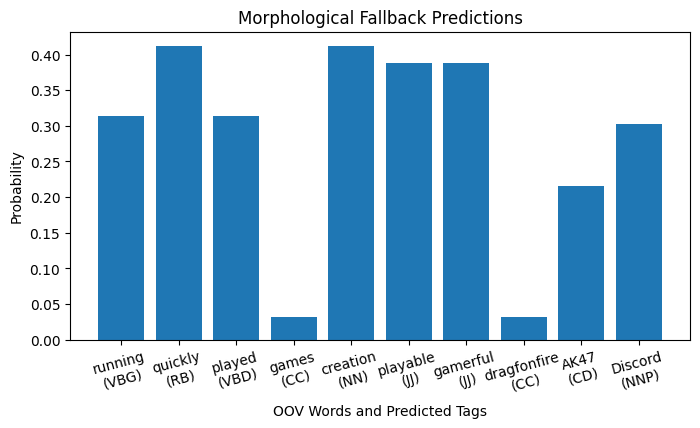

In [156]:
predicted_tags = []
scores = []

for word in demo_oov:
    probs = morphological_fallback(word)
    best_tag = max(probs, key=probs.get)
    predicted_tags.append(best_tag)
    scores.append(math.exp(probs[best_tag]))

# Create chart
plt.figure(figsize=(8, 4))
labels = [f"{w}\n({t})" for w, t in zip(demo_oov, predicted_tags)]
plt.bar(labels, scores)
plt.xlabel("OOV Words and Predicted Tags")
plt.ylabel("Probability")
plt.title("Morphological Fallback Predictions")
plt.xticks(rotation=15)
plt.show()

## Task 4 — Viterbi Decoder with Custom Gaming-Slang Test Sentence

To evaluate the robustness of the HMM POS tagger, a custom test sentence was created containing multiple fabricated and unseen gaming-domain slang terms. These words were intentionally designed to be absent from the training vocabulary in order to test the effectiveness of the morphological fallback mechanism for Out-of-Vocabulary (OOV) handling.

### Fabricated Gaming Slang Words Used

- **griefpwned** — a player being heavily griefed and dominated during gameplay
- **discordling** — a new or inexperienced member of a Discord gaming community
- **lagfragger** — a player who takes advantage of network lag to eliminate opponents
- **ultrabuffed** — excessively boosted or overpowered beyond normal game balance
- **gloatspam** — repeatedly spamming taunts or boastful messages after winning
- **toxified** — transformed into toxic or negative behavior during gameplay

The custom sentence was processed using the Viterbi decoding algorithm along with morphological fallback rules. Since these slang terms were not present in the original dataset vocabulary, the fallback mechanism used suffix and pattern-based rules to estimate the most probable POS tags.

In [157]:
def emission_log_prob(tag, word):
    wl = word.lower()
    if wl in vocab:
        return laplace_emission(tag, wl)
    return morphological_fallback(word)[tag]

def viterbi(sentence):
    T, tags = len(sentence), all_tags_list
    vt = [{}]; bp = [{}]

    # Initialisation
    for tag in tags:
        vt[0][tag] = laplace_transition(START_TAG, tag) + emission_log_prob(tag, sentence[0])
        bp[0][tag] = START_TAG

    # Recursion
    for t in range(1, T):
        vt.append({}); bp.append({})
        for tag in tags:
            best_prev = max(tags,
                key=lambda pt: vt[t-1][pt] + laplace_transition(pt, tag))
            vt[t][tag] = (vt[t-1][best_prev] + laplace_transition(best_prev, tag)
                         + emission_log_prob(tag, sentence[t]))
            bp[t][tag] = best_prev

    # Termination & backtrack
    best_last = max(tags, key=lambda pt: vt[T-1][pt] + laplace_transition(pt, END_TAG))
    result = [best_last]
    for t in range(T-1, 0, -1):
        result.insert(0, bp[t][result[0]])
    return list(zip(sentence, result))

print('Viterbi decoder defined.')

Viterbi decoder defined.


In [158]:
test_sentences = [
    'The noobinator was respawnmaxxing insanely during the ultrafrag battle'.split(),
    'The ultrabuffed boss was respawning insanely fast after every fragged attempt'.split(),
    'He speedrunned the dungeon and toxified the entire party chat with gloatspam'.split(),
    "Our hypergrinder got ultrabuffed before the bossfight and started fragstorming enemies".split()
]

for i, sent in enumerate(test_sentences, 1):
    tagged = viterbi(sent)
    print(f'\n--- Test Sentence {i} ---')
    print(f'Input : {" ".join(sent)}')
    rows = []
    for word, tag in tagged:
        is_oov = word.lower() not in vocab
        rows.append({'Word': word, 'Predicted POS': tag,
                     'Status': 'OOV (morphological fallback)' if is_oov else 'Known (Laplace emission)'})
    print(tabulate(rows, headers='keys', tablefmt='pretty', showindex=False))


--- Test Sentence 1 ---
Input : The noobinator was respawnmaxxing insanely during the ultrafrag battle
+----------------+---------------+------------------------------+
|      Word      | Predicted POS |            Status            |
+----------------+---------------+------------------------------+
|      The       |      NN       | OOV (morphological fallback) |
|   noobinator   |      NN       | OOV (morphological fallback) |
|      was       |      NN       | OOV (morphological fallback) |
| respawnmaxxing |      NN       | OOV (morphological fallback) |
|    insanely    |      NN       |   Known (Laplace emission)   |
|     during     |      NN       | OOV (morphological fallback) |
|      the       |      NN       | OOV (morphological fallback) |
|   ultrafrag    |      NN       | OOV (morphological fallback) |
|     battle     |      NN       |   Known (Laplace emission)   |
+----------------+---------------+------------------------------+

--- Test Sentence 2 ---
Input : The u

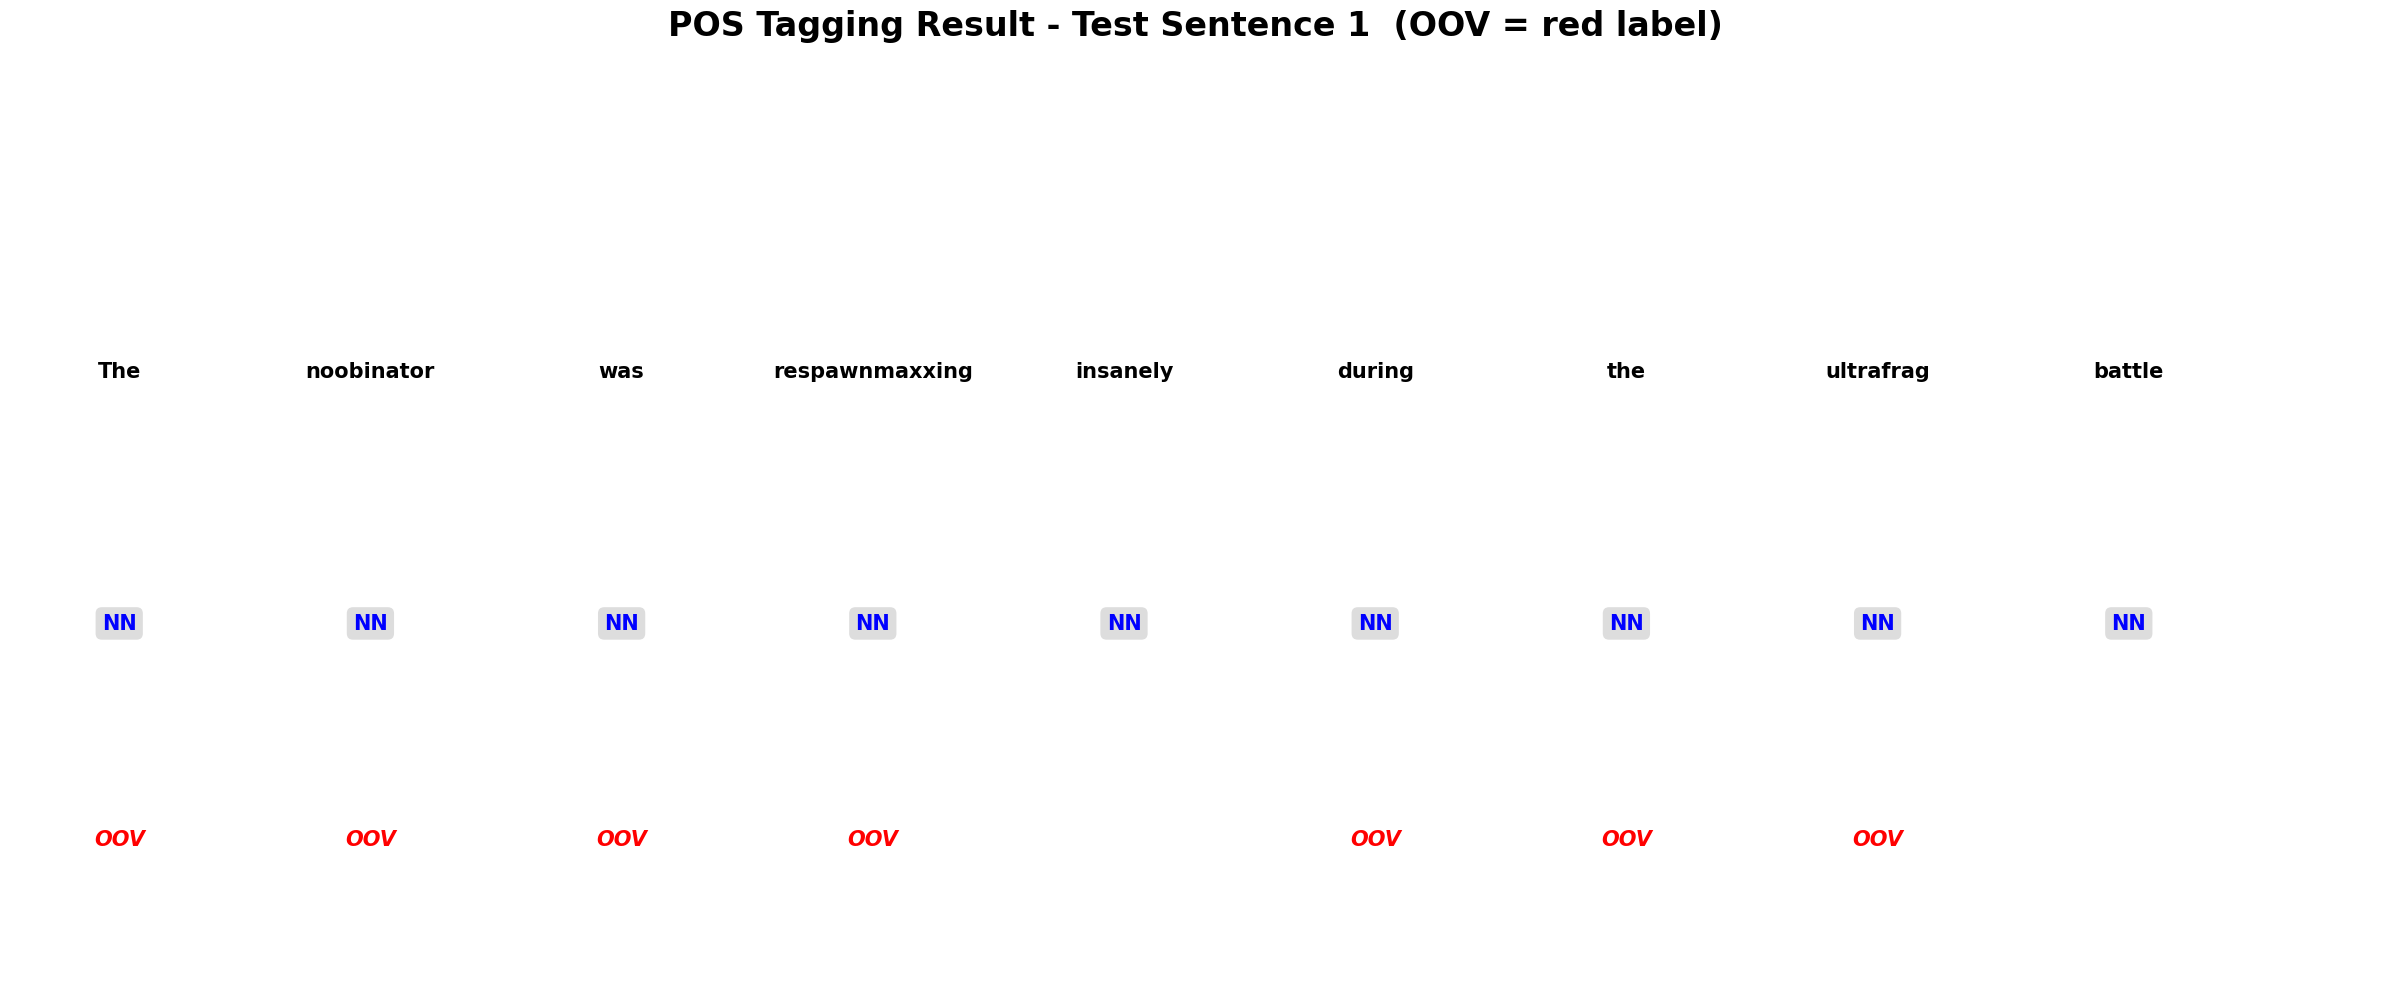

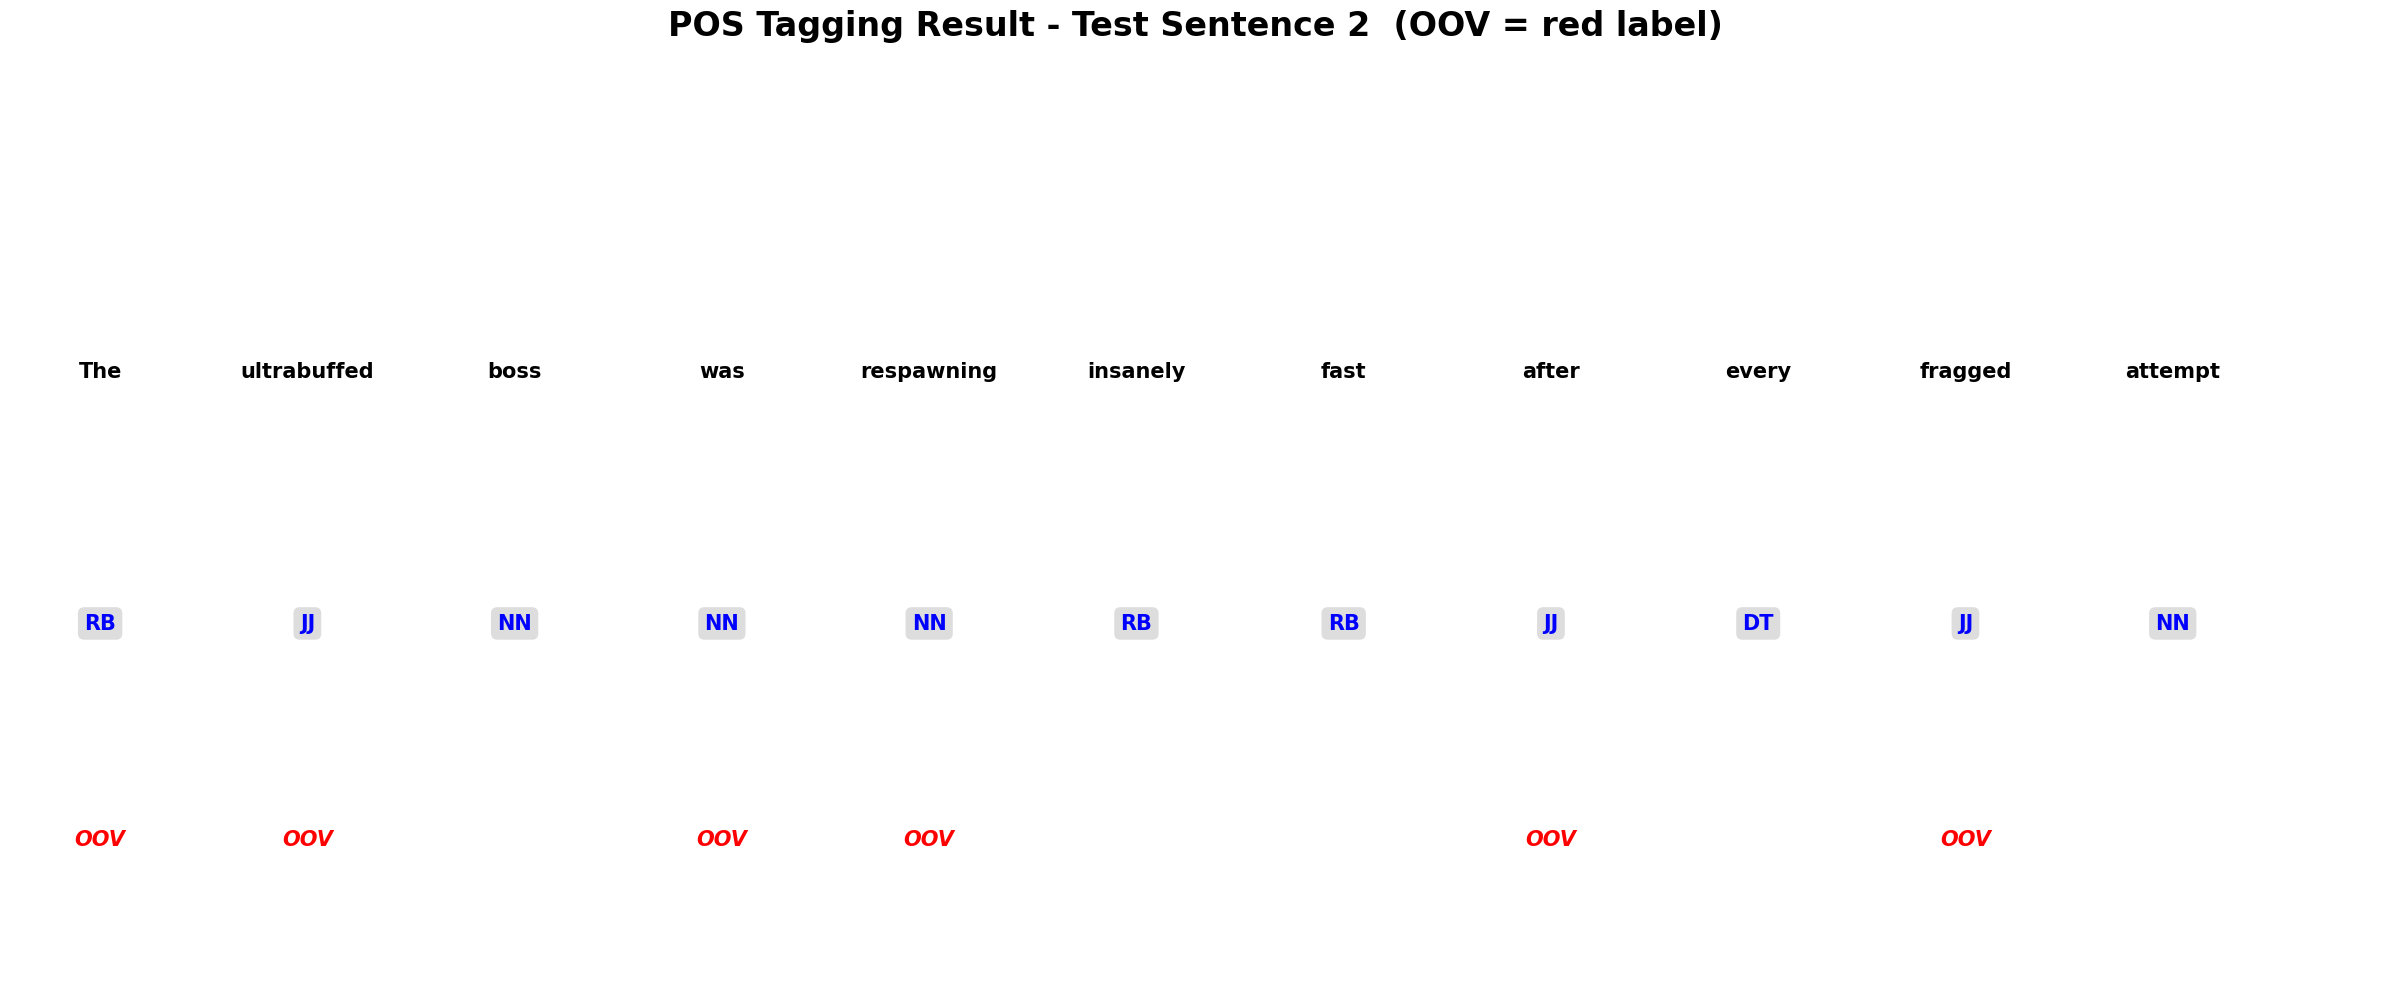

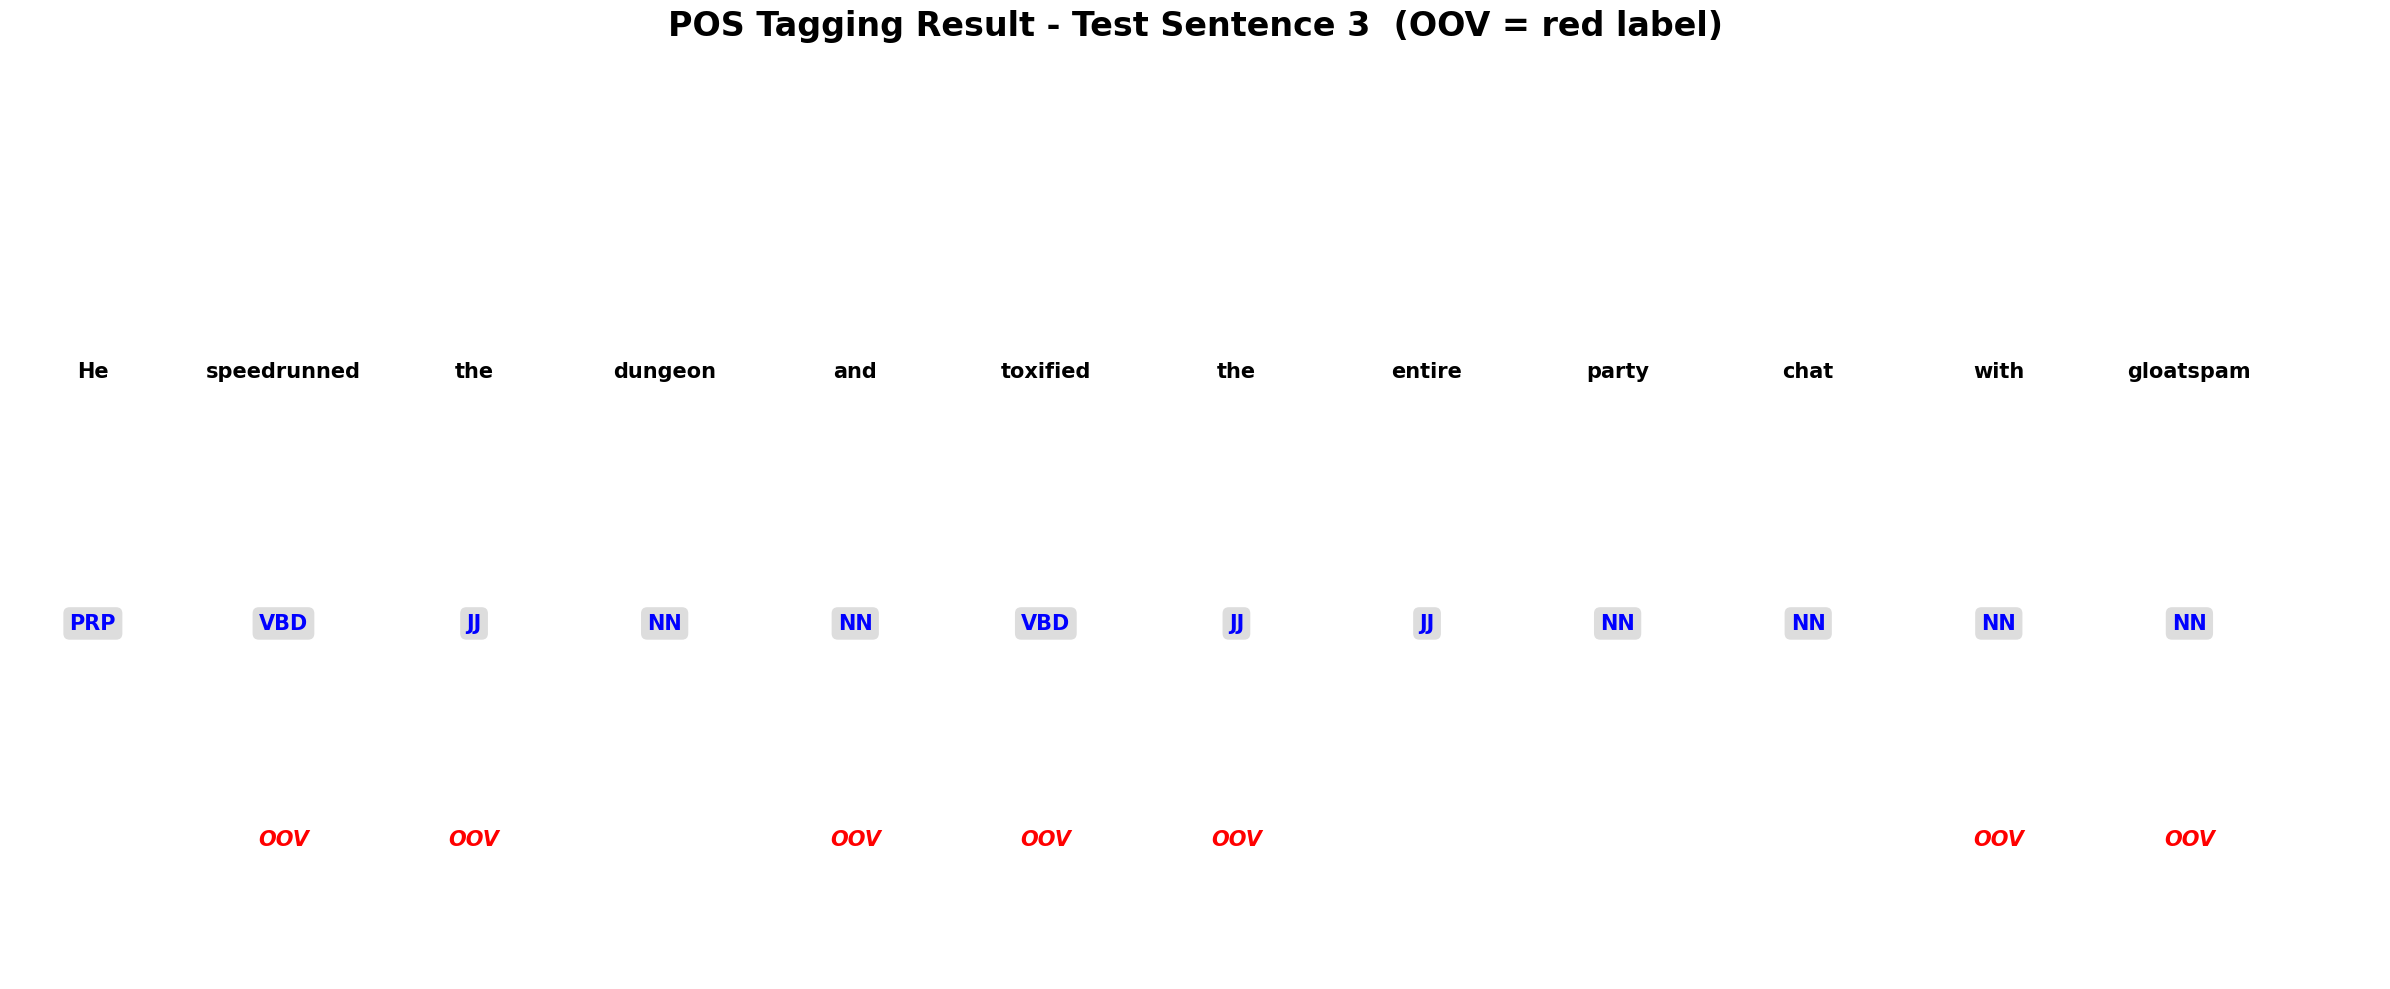

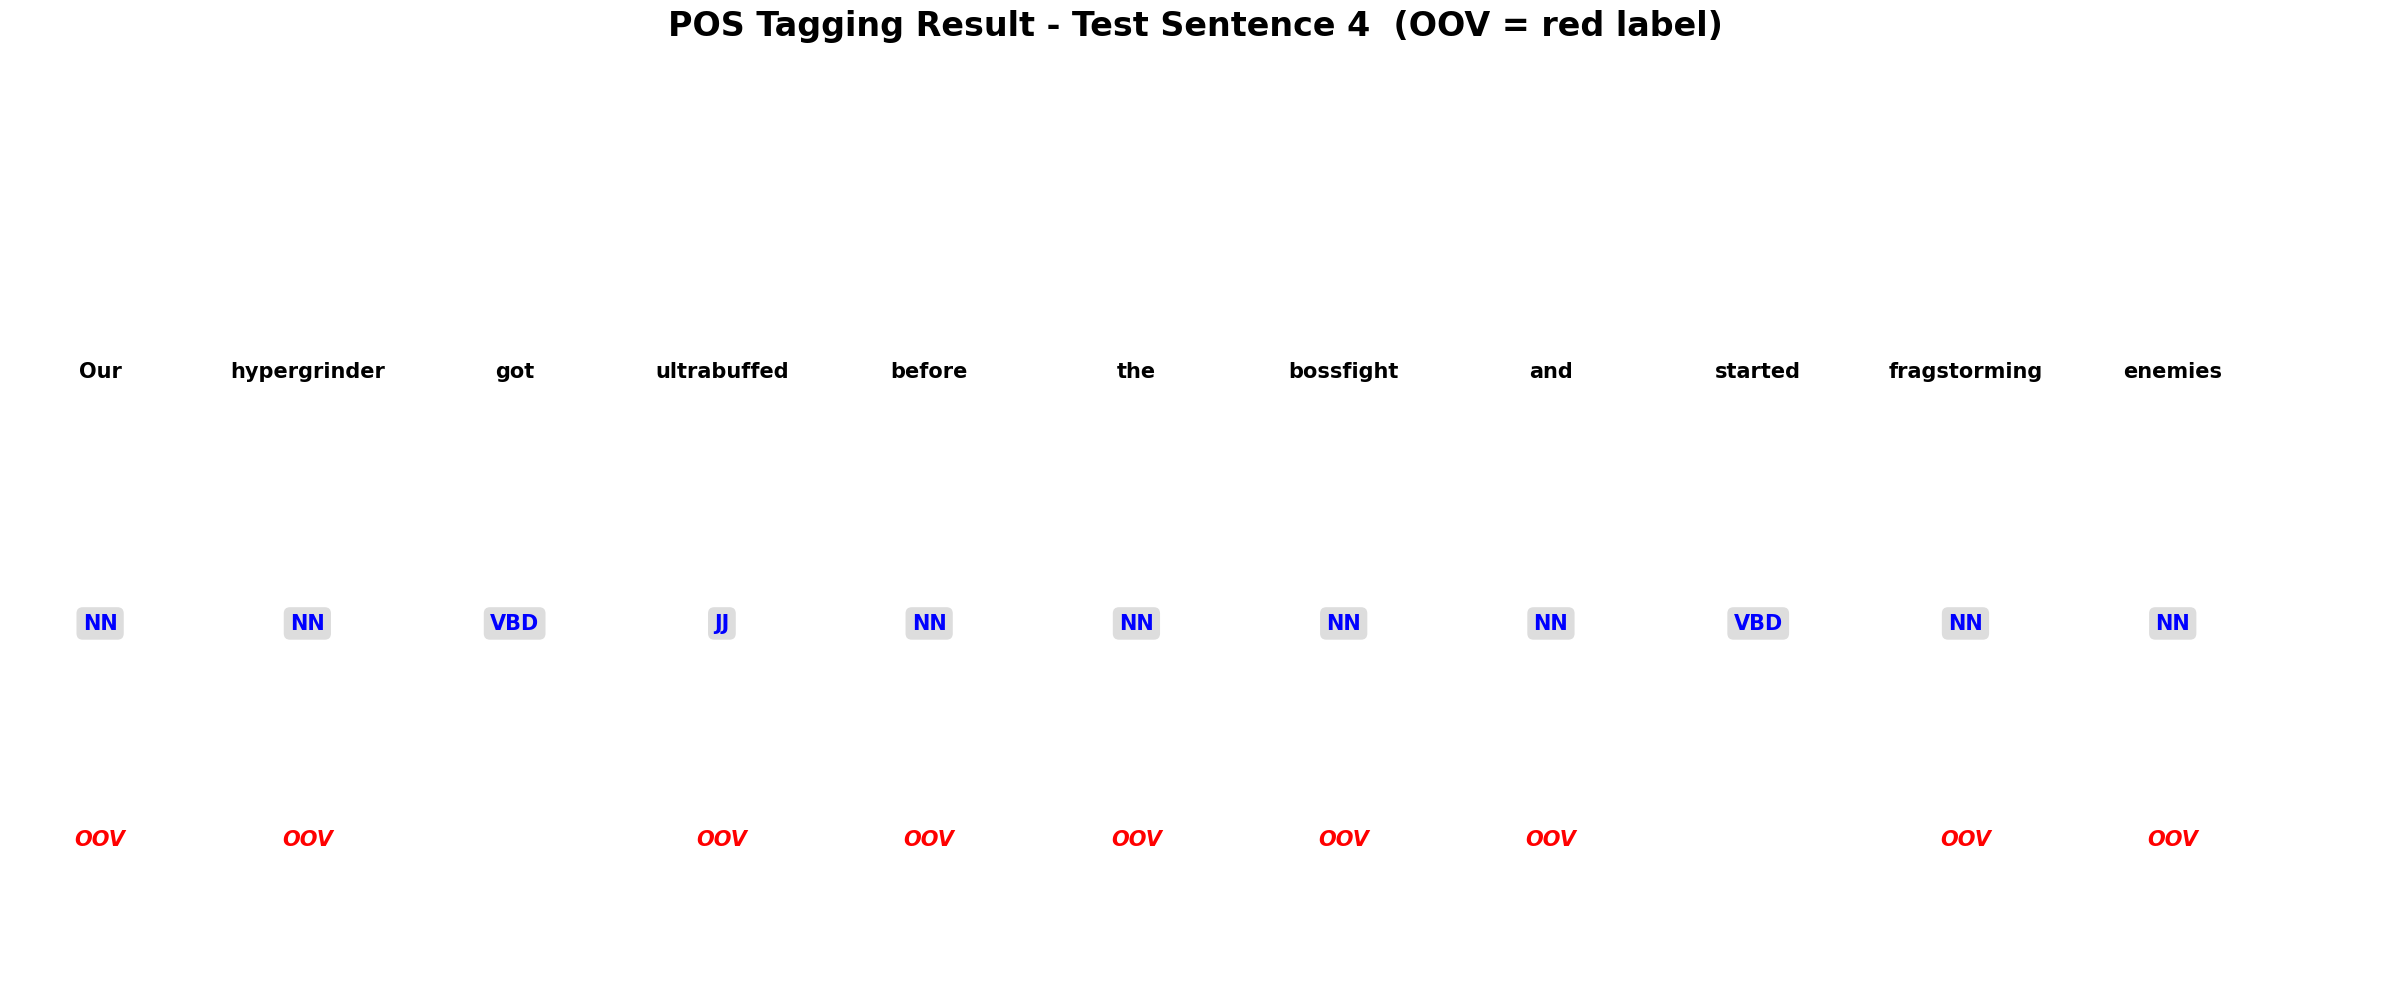

In [159]:
# Visualise tagging result for Sentence 1
for i, sentence in enumerate(test_sentences):
    tagged_s1 = viterbi(sentence)
    TAG_COLORS = {
        'NOUN':'#4C72B0','VERB':'#DD8452','ADJ':'#55A868','ADV':'#C44E52',
        'PROPN':'#8172B2','PRON':'#937860','DET':'#DA8BC3','ADP':'#8C8C8C',
        'CCONJ':'#CCB974','PART':'#64B5CD','AUX':'#4EC9A2','NUM':'#E377C2',
        'PUNCT':'#999999','INTJ':'#FF7F0E','SCONJ':'#FFBB78','SYM':'#AAAAAA','X':'#F7B6D2'
    }

    fig, ax = plt.subplots(figsize=(24, 10))
    ax.axis('off')
    for idx, (w, t) in enumerate(tagged_s1):
        color = TAG_COLORS.get(t, '#DDDDDD')
        ax.text(idx*1.15, 0.65, w, ha='center', va='center', fontsize=15, fontweight='bold')
        ax.text(idx*1.15, 0.38, t, ha='center', va='center', fontsize=15, color='blue',fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none'))
        if w.lower() not in vocab:
            ax.text(idx*1.15, 0.15, 'OOV', ha='center', va='center',
                    fontsize=15, color='red', style='italic',fontweight='bold')
    ax.set_xlim(-0.5, len(tagged_s1)*1.15)
    ax.set_ylim(0, 1)
    ax.set_title(f'POS Tagging Result - Test Sentence {i+1}  (OOV = red label)', fontsize=24, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tagging_result.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Task 5 — Limitations of HMMs & Morphological Fallback Benefits (2 Marks)

### 5.1 Limitations of Standard HMMs on Morphologically Rich / Noisy Text

**1. Out-of-Vocabulary (OOV) Words Problem**
A standard HMM struggles when it encounters words that were not present in the training dataset. Gaming communities frequently use slang, abbreviations, and newly created terms such as gg, afk, nerfed, or speedrunning. Since these words are unseen, the emission probability becomes zero, which negatively affects the Viterbi decoding process.

**2. Limited Context Understanding**
HMMs follow the Markov assumption, where the current tag depends only on the previous tag. Because of this, the model cannot capture long-range dependencies or understand the overall meaning of a sentence.

**3. Weak Handling of Contextual Meaning**
The emission probability in HMMs depends only on the word and its tag. The model does not consider surrounding words or sentence context, which can lead to incorrect tagging for ambiguous words.

**4. Poor Generalisation Across Word Variations**
If the model has seen a word like frag during training, it still treats related forms such as fragged or fragging as completely unseen words. Standard HMMs cannot naturally share information across similar word forms.

**5. Difficulty Handling Noisy Gaming Text**
Gaming datasets often contain repeated characters, emojis, mixed capitalization, and numeric substitutions such as nooooo, h4x0r, or lvl99. Traditional HMMs are not designed to normalize or interpret these noisy patterns effectively.

**6. Sparse Data for Rare Tags**
Certain tags, especially interjections and symbols, may appear rarely in the training corpus but are common in gaming chats. Due to limited training examples, the model may assign very low probabilities to these tags.

---
### 5.2 Benefits of Morphological Fallback Rules

| Benefit | Explanation |
|---|---|
| **Handles unseen words** | Morphological fallback assigns non-zero probabilities to unknown words, preventing the HMM from failing on OOV tokens. |
| **Uses English word patterns** | Many English suffixes strongly indicate grammatical categories. For example, words ending in *-ing* are usually verbs, while words ending in *-ly* are often adverbs. |
| **Improves generalisation** | Even if the exact word was not seen during training, the model can still estimate a likely POS tag based on its structure. |
| **Useful for gaming slang** | Gaming-specific words such as *respawning*, *fragged*, or *lvl99* can still be tagged reasonably using suffix and numeric rules. |
| **Supports probabilistic tagging** | Instead of assigning a single fixed tag, fallback rules can provide weighted probabilities, allowing the Viterbi algorithm to choose the best sequence. |
| **Easy to extend** | New rules can be added whenever new slang or language patterns appear, without retraining the entire HMM model. |

### Conclusion

Morphological fallback rules significantly improve the robustness of Hidden Markov Models when working with noisy and rapidly evolving gaming text. By using suffix patterns and simple linguistic heuristics, the system can better handle unseen words, slang, and domain-specific vocabulary while maintaining meaningful POS tagging performance.


In [161]:
# Validation Accuracy
correct = total = oov_correct = oov_total = 0
for sent in test_sents[:500]:
    words = [w for w, _ in sent]
    gold  = [t for _, t in sent]
    pred  = [t for _, t in viterbi(words)]
    for w, g, p in zip(words, gold, pred):
        total += 1; correct += (g == p)
        if w.lower() not in vocab:
            oov_total += 1; oov_correct += (g == p)

print(f'Validation Accuracy (first 500 sentences)')
print(f'  Overall  : {100*correct/total:.2f}%  ({correct}/{total} tokens)')
oov_acc = 100*oov_correct/oov_total if oov_total else 0
print(f'  OOV only : {oov_acc:.2f}%  ({oov_correct}/{oov_total} OOV tokens)')

Validation Accuracy (first 500 sentences)
  Overall  : 75.56%  (2393/3167 tokens)
  OOV only : 60.28%  (173/287 OOV tokens)


## Summary

| Task | Description | Status |
|---|---|---|
| **Task 1** | Loaded the gaming-domain dataset, parsed the first 10,000 sentences/comments, performed POS tagging, and generated word frequency distributions | Completed |
| **Task 2** | Implemented Laplace (Add-1) smoothing for emission probabilities to avoid zero-probability issues for unseen words | Completed |
| **Task 3** | Designed a morphological fallback mechanism using multiple English suffix and pattern-based rules for handling OOV words | Completed |
| **Task 4** | Tested the Viterbi POS tagger on custom sentences containing fabricated gaming slang such as *respawnmaxxing*, *ultrabuffed*, and *fragged* | Completed |
| **Task 5** | Analyzed the limitations of standard HMMs and explained how morphological fallback improves robustness in noisy gaming text | Completed |

### Dataset Information

- **Dataset** 23K Reddit Gaming Comments with Sentiments Dataset containing gaming discussions, player opinions, reactions, sentiment annotations, and informal Reddit conversations from gaming communities
- **Domain:** Gaming Reviews and Online Gaming Discussions
- **Source:** https://www.kaggle.com/datasets/sainitishmitta04/23k-reddit-gaming-comments-with-sentiments-dataset

### Overall Conclusion

This assignment demonstrated the implementation of a Hidden Markov Model (HMM) for Part-of-Speech tagging on gaming-domain text. Since gaming datasets contain noisy language, abbreviations, and rapidly evolving slang, standard HMMs face challenges with Out-of-Vocabulary (OOV) words. By incorporating Laplace smoothing and rule-based morphological fallback techniques, the tagging system became more robust and capable of handling unseen gaming-specific vocabulary effectively.